# SECTION 1: LOAN ELIGIBILITY DATA ANALYSIS & CLEANING


Is section mein hum Loan dataset ko load karenge, uski missing values ko clean karenge, aur behtareen EDA (Exploratory Data Analysis) graphs banayenge.

In [5]:
# ================================
# Step 1: Import Libraries
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# ================================
# Step 2: Load Dataset
# ================================

df = pd.read_csv("loan-train.csv")

# Display first rows
print(df.head())

# Shape of dataset
print("Rows and Columns :", df.shape)

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

### 1.Basic information

In [6]:
print(df.info())
print(df.describe())
print(df.describe(include='object'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   object 
 1   Gender             1601 non-null   object 
 2   Married            1611 non-null   object 
 3   Dependents         1599 non-null   object 
 4   Education          1614 non-null   object 
 5   Self_Employed      1582 non-null   object 
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   object 
 12  Loan_Status        1614 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 164.1+ KB
None
       ApplicantIncome  CoapplicantIncome   LoanAmount  Loan_Amount_Term  \
count      1614.000000      

### 2.Check missing valuees

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


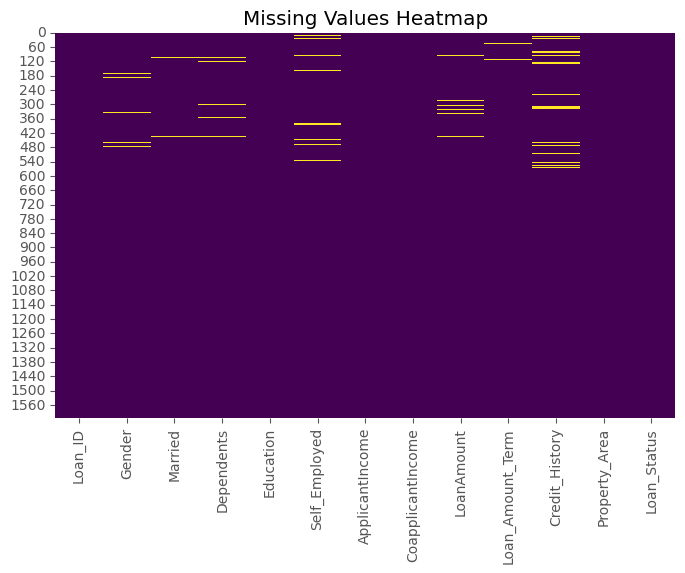

In [7]:
print(df.isnull().sum())

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### 3.Check duplicate records

In [8]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


### 4. Check data types

In [10]:
print(df.dtypes)

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


## Data Cleaning

### Fill missing values 
#### Categorial columns 

In [14]:
df['Gender'].fillna(df['Gender'].mode()[0], )

df['Married'].fillna(df['Married'].mode()[0], )

df['Dependents'].fillna(df['Dependents'].mode()[0], )

df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], )

df['Credit_History'].fillna(df['Credit_History'].mode()[0], )

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1609    0.0
1610    1.0
1611    0.0
1612    0.0
1613    1.0
Name: Credit_History, Length: 1614, dtype: float64

### Numerical column

In [16]:
df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median() )

0       360.0
1       360.0
2       360.0
3       360.0
4       360.0
        ...  
1609    180.0
1610    360.0
1611    360.0
1612    360.0
1613    240.0
Name: Loan_Amount_Term, Length: 1614, dtype: float64

In [17]:
print(df.isnull().sum())


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


## EXPLORATORY DATA ANALYSIS
### Target variable distribution 

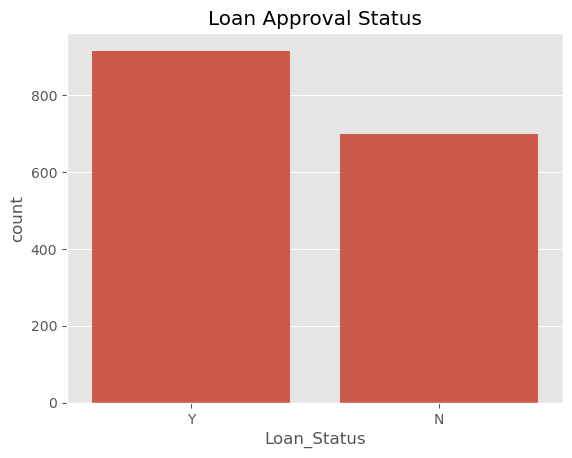

In [18]:
sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Status")

plt.show()

### Gender distribution 

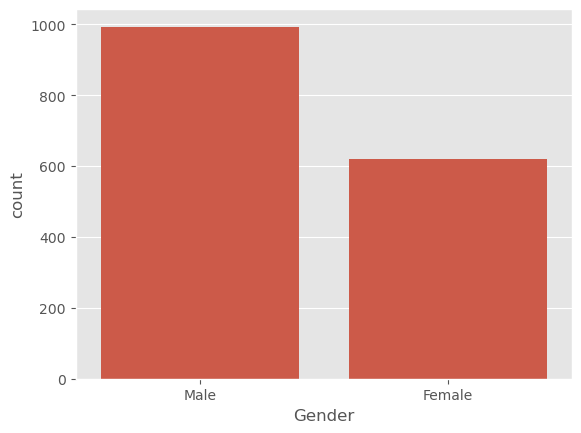

In [19]:
sns.countplot(x='Gender', data=df)

plt.show()

### Education distribution 

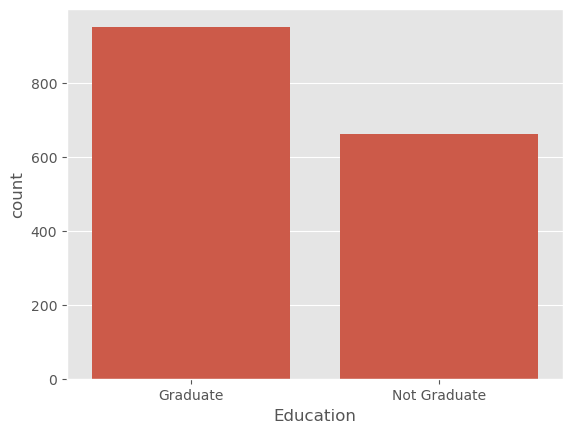

In [20]:
sns.countplot(x='Education', data=df)

plt.show()

### Property Area 

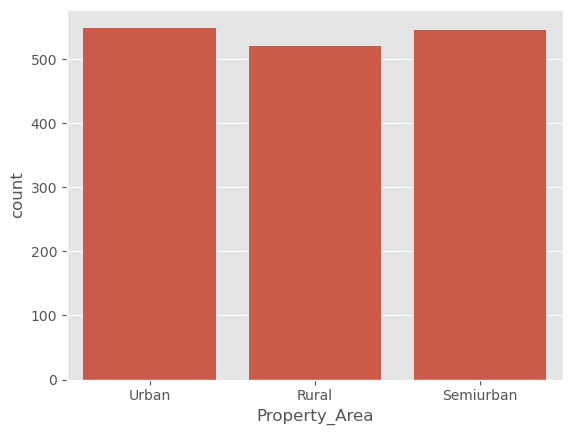

In [21]:
sns.countplot(x='Property_Area', data=df)

plt.show()

### Married vs Loan status 

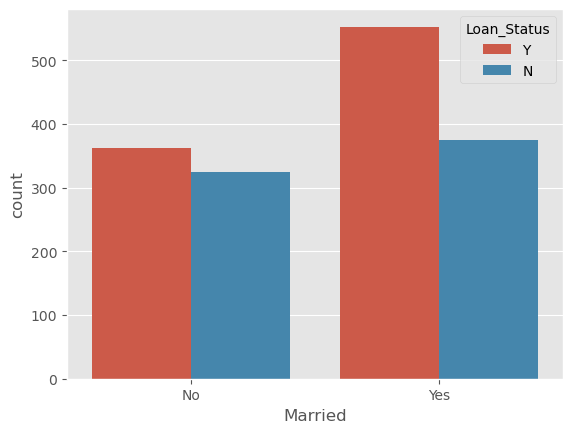

In [22]:
sns.countplot(x='Married',
              hue='Loan_Status',
              data=df)

plt.show()

### Education vs Loan status 

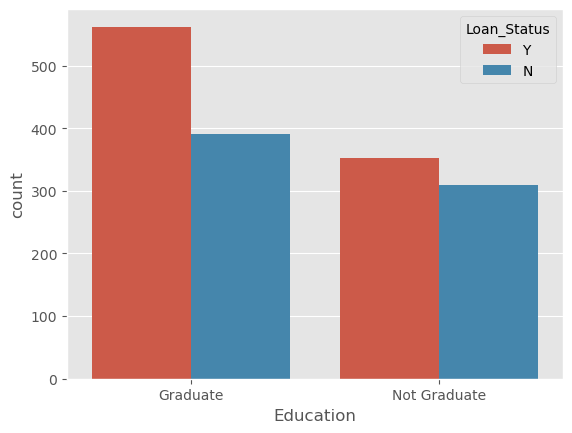

In [23]:
sns.countplot(x='Education',
              hue='Loan_Status',
              data=df)

plt.show()

### Credit history vs Loan status 

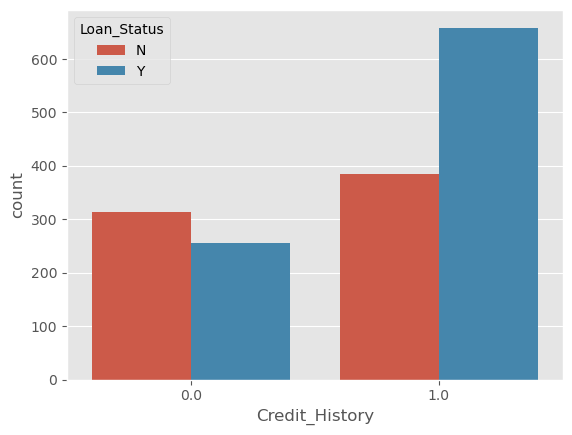

In [24]:
sns.countplot(x='Credit_History',
              hue='Loan_Status',
              data=df)

plt.show()

### Applicant income distribution 

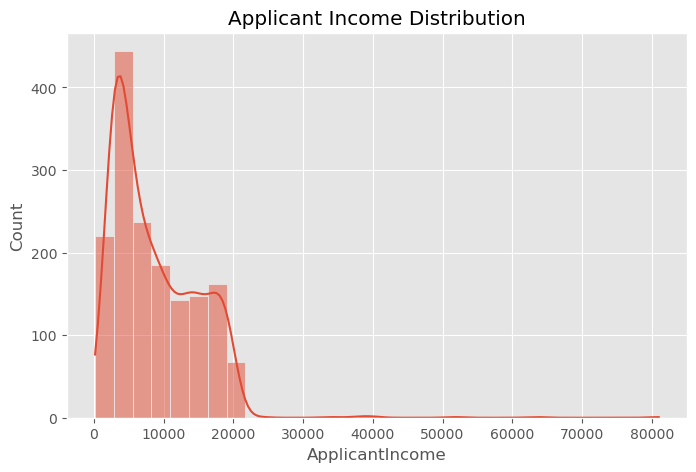

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['ApplicantIncome'],
             bins=30,
             kde=True)

plt.title("Applicant Income Distribution")

plt.show()

### Loan amount distribution 

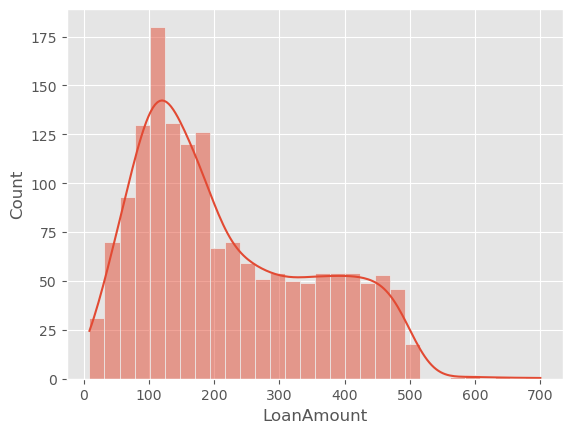

In [26]:
sns.histplot(df['LoanAmount'],
             bins=30,
             kde=True)

plt.show()

### Box plot

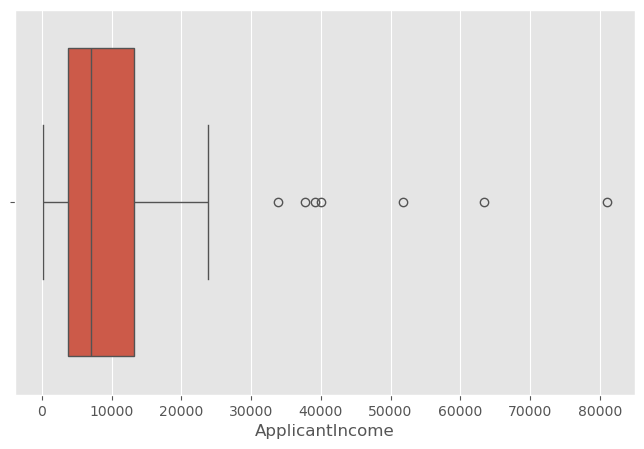

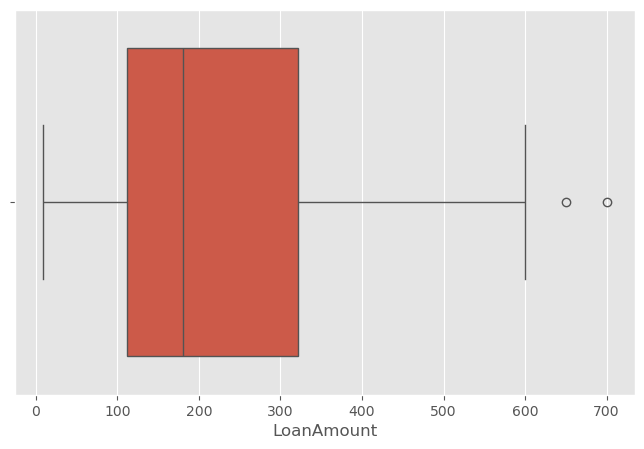

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['ApplicantIncome'])

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(x=df['LoanAmount'])

plt.show()

### Pair plot

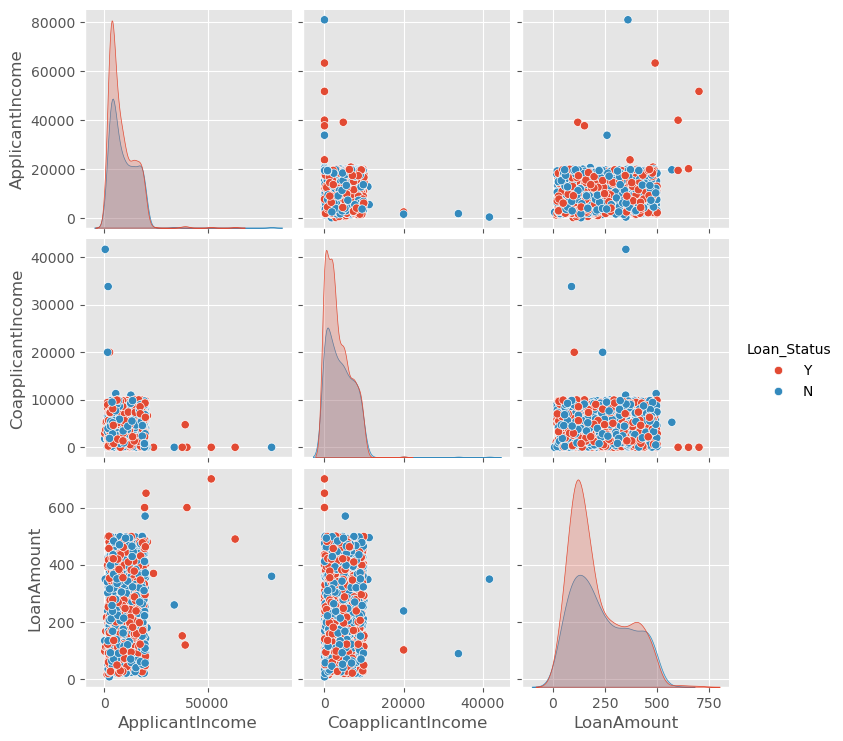

In [28]:
sns.pairplot(df[['ApplicantIncome',
                 'CoapplicantIncome',
                 'LoanAmount',
                 'Loan_Status']],
             hue='Loan_Status')

plt.show()

### Loan amount vs Income 

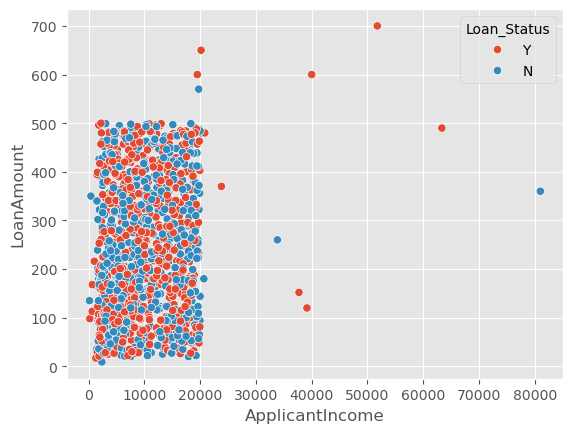

In [29]:
sns.scatterplot(x='ApplicantIncome',
                y='LoanAmount',
                hue='Loan_Status',
                data=df)

plt.show()

## Save clean dataset

In [30]:
df.to_csv("cleaned_loan_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


# Section 2: Adult Census Income Dataset

### Load dataset

In [31]:
adult = pd.read_csv("adult.csv")

adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


### Dataset info 

In [32]:
adult.head()

adult.tail()

adult.shape

adult.columns

adult.info()

adult.describe()

adult.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


### Missing values

In [37]:
adult.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

### Heatmap

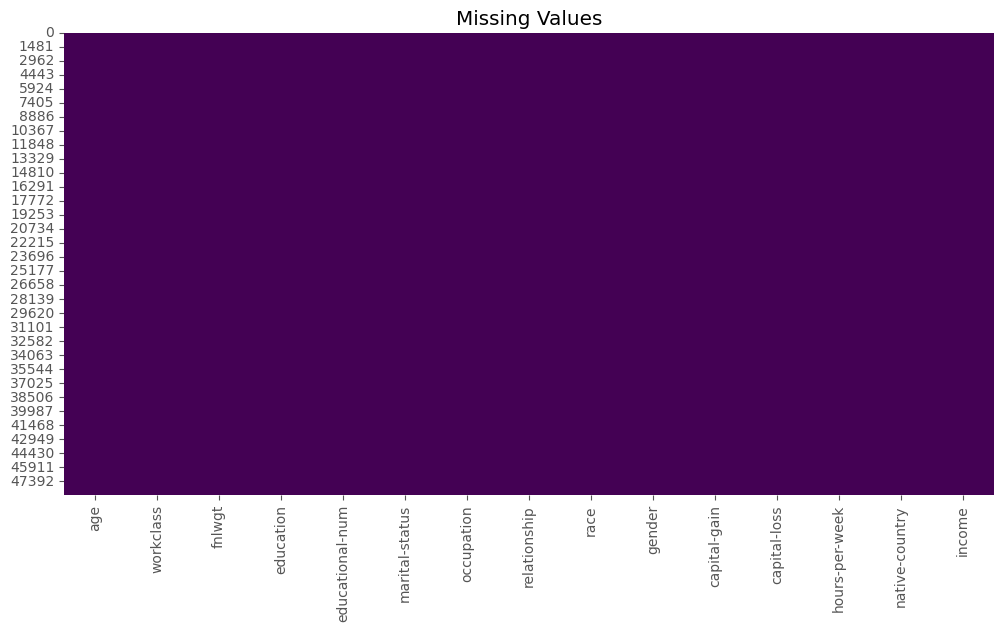

In [39]:
plt.figure(figsize=(12,6))
sns.heatmap(adult.isnull(),cbar=False,cmap='viridis')
plt.title("Missing Values")
plt.show()

## Duplicate records

In [40]:
adult.duplicated().sum()

np.int64(52)

## Datatypes

In [42]:
adult.dtypes

age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

### Unique value of every column 

In [43]:
for col in adult.columns:
    print("\n",col)
    print(adult[col].unique())


 age
[25 38 28 44 18 34 29 63 24 55 65 36 26 58 48 43 20 37 40 72 45 22 23 54
 32 46 56 17 39 52 21 42 33 30 47 41 19 69 50 31 59 49 51 27 57 61 64 79
 73 53 77 80 62 35 68 66 75 60 67 71 70 90 81 74 78 82 83 85 76 84 89 88
 87 86]

 workclass
['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

 fnlwgt
[226802  89814 336951 ... 129912 255835 257302]

 education
['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']

 educational-num
[ 7  9 12 10  6 15  4 13 14 16  3 11  5  8  2  1]

 marital-status
['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']

 occupation
['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales' 'Priv-house-ser

## Data cleaning 

### check missing values 

adult.isnull().sum()

In [51]:
for col in adult.select_dtypes(include='object'):
    adult[col].fillna(adult[col].mode()[0])

## Univarite Analysis

### Age distribution 

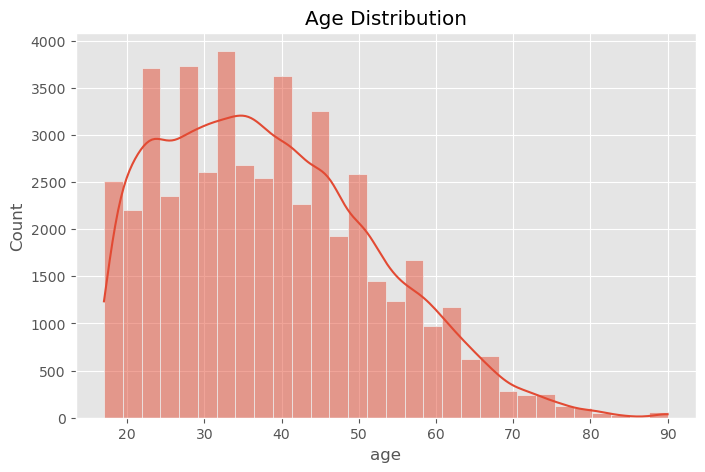

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(adult['age'],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

### Workclass

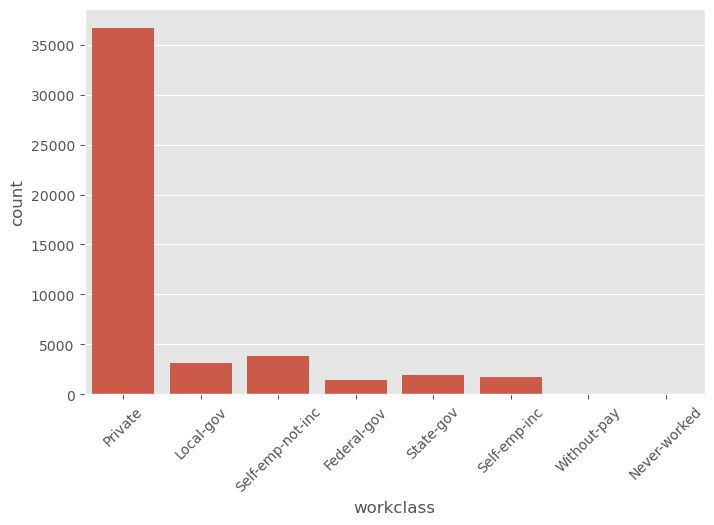

In [53]:
plt.figure(figsize=(8,5))
sns.countplot(x='workclass',data=adult)
plt.xticks(rotation=45)
plt.show()

### Education 

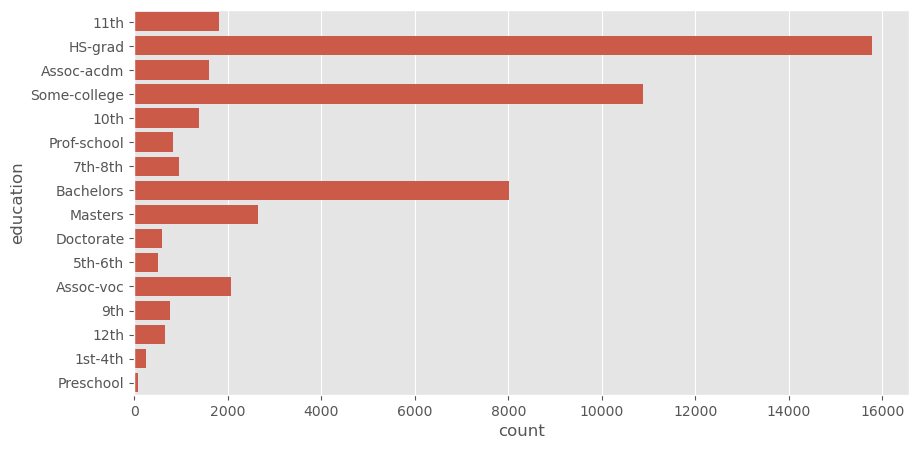

In [54]:
plt.figure(figsize=(10,5))
sns.countplot(y='education',data=adult)
plt.show()

### Marital status

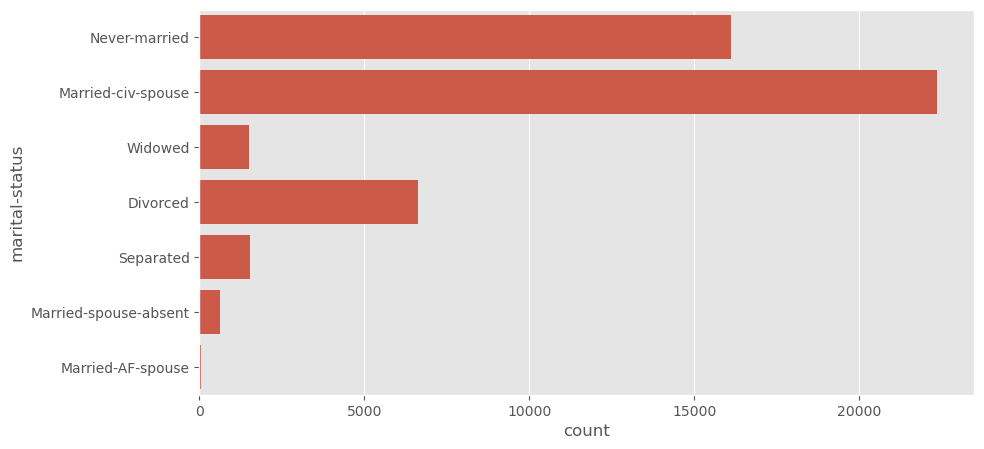

In [55]:
plt.figure(figsize=(10,5))
sns.countplot(y='marital-status',data=adult)
plt.show()

### Occupation 

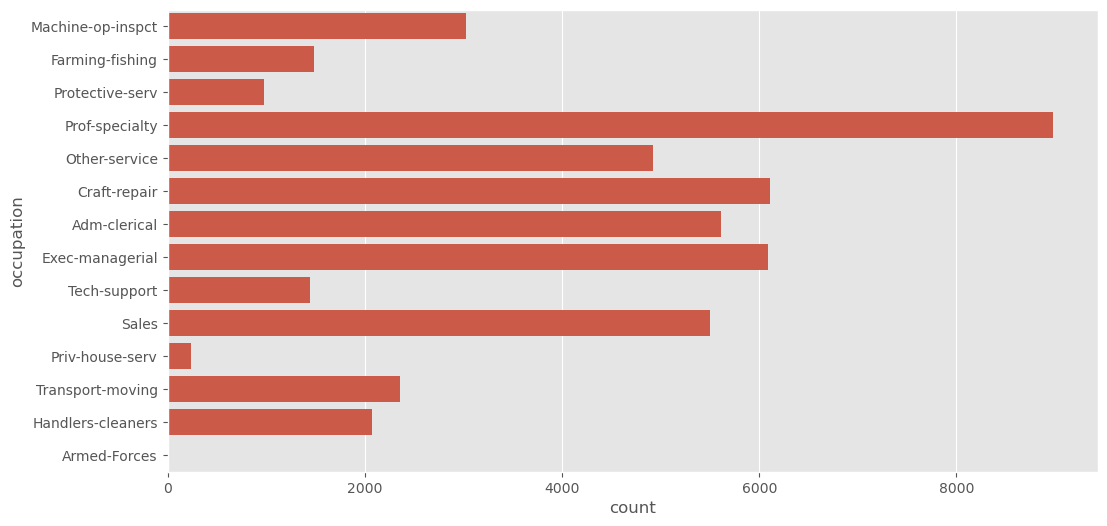

In [58]:
plt.figure(figsize=(12,6))
sns.countplot(y='occupation',data=adult)
plt.show()

### Relationship

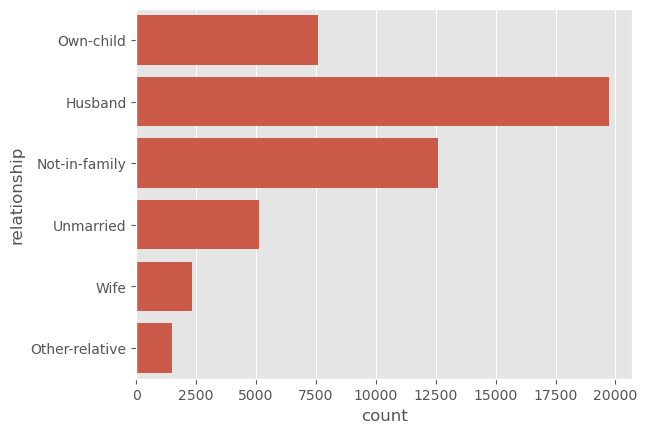

In [59]:
sns.countplot(y='relationship',data=adult)
plt.show()

### Race 

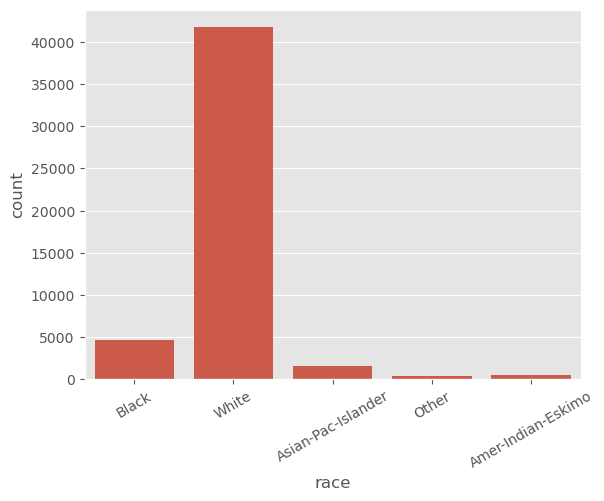

In [61]:
sns.countplot(x='race',data=adult)
plt.xticks(rotation=30)
plt.show()

### Native country

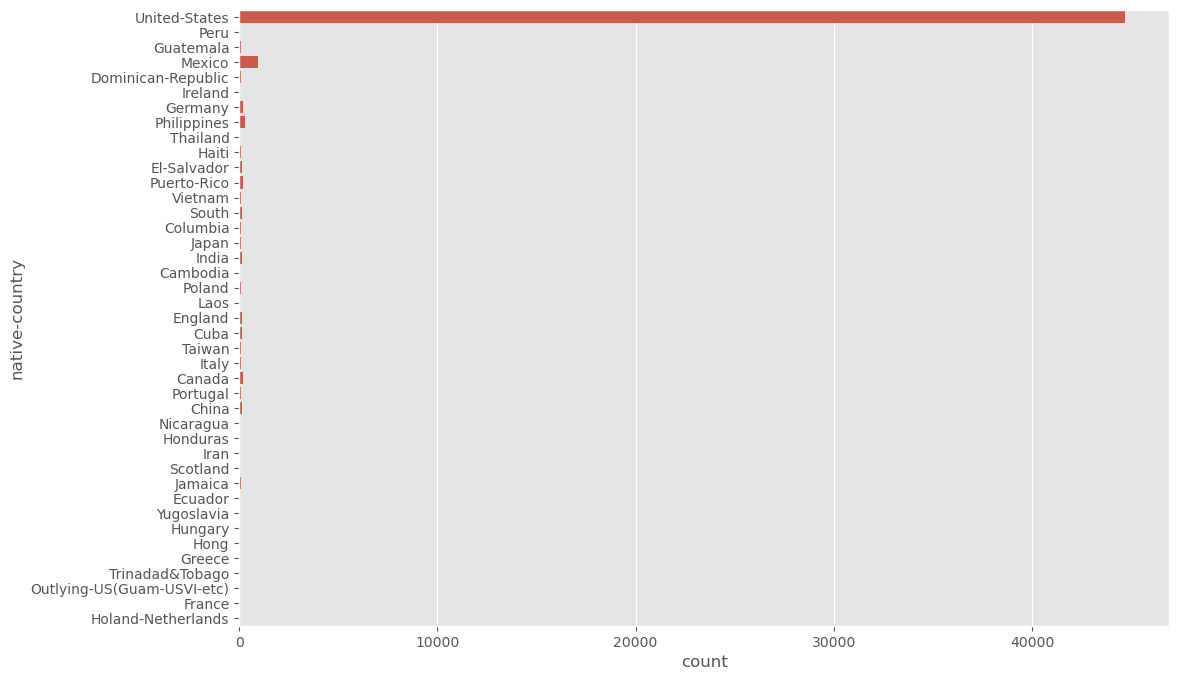

In [68]:
plt.figure(figsize=(12,8))
sns.countplot(y='native-country',data=adult)
plt.show()

### income distribution 

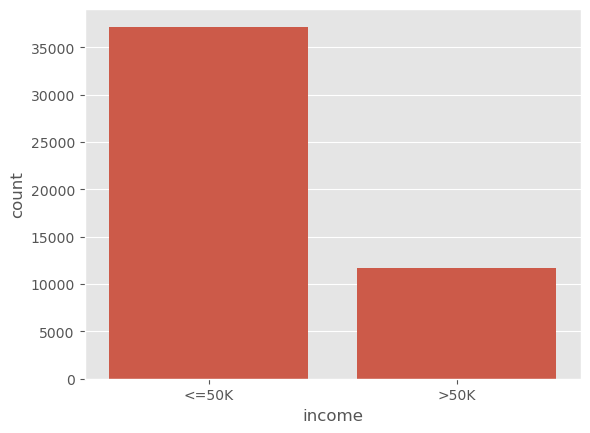

In [69]:
sns.countplot(x='income',data=adult)
plt.show()

### Hours per week 

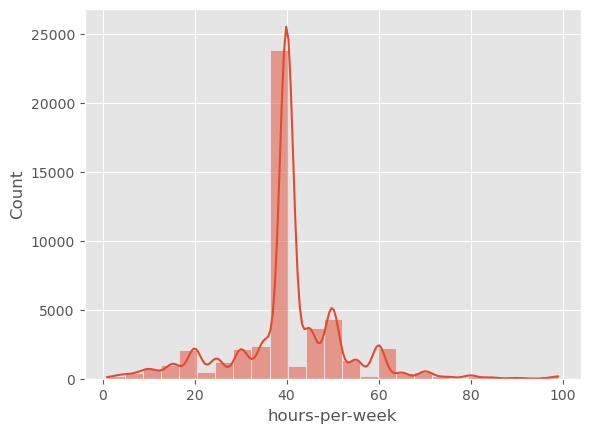

In [70]:
sns.histplot(adult['hours-per-week'],bins=25,kde=True)
plt.show()

### Capital gain and loss

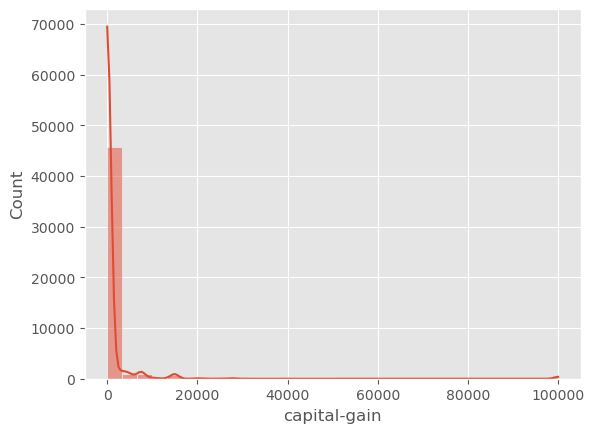

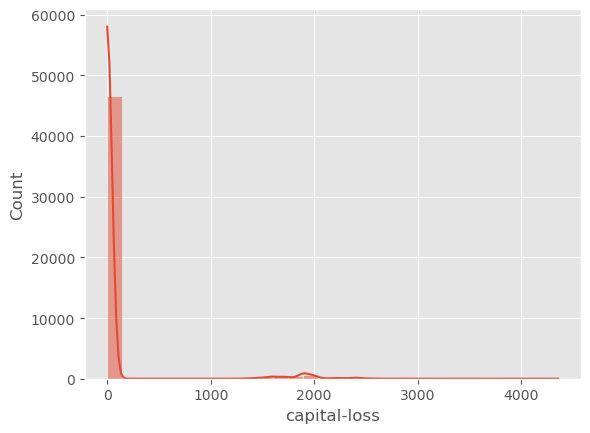

In [71]:
sns.histplot(adult['capital-gain'],bins=30,kde=True)
plt.show()

sns.histplot(adult['capital-loss'],bins=30,kde=True)
plt.show()

## boxplots

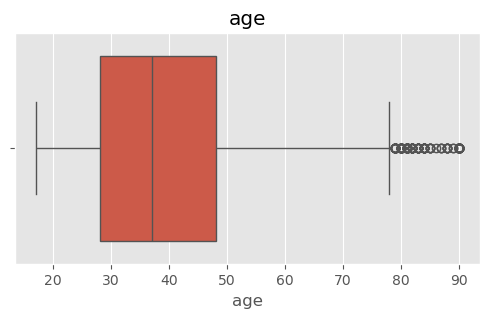

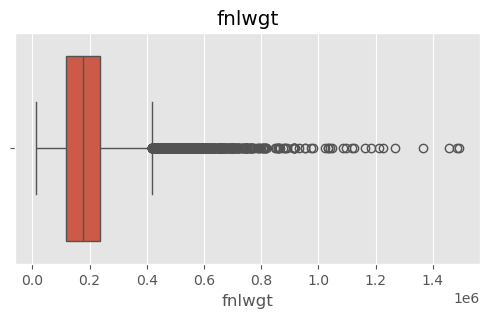

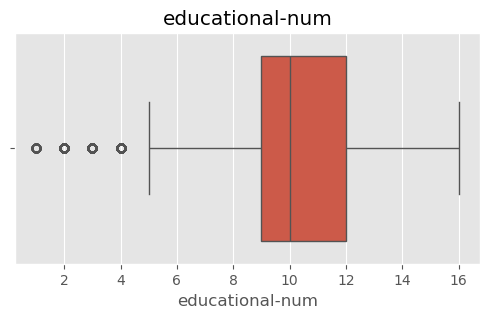

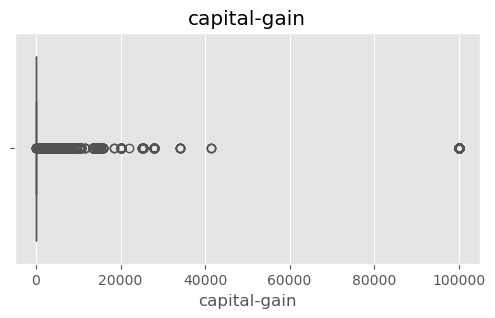

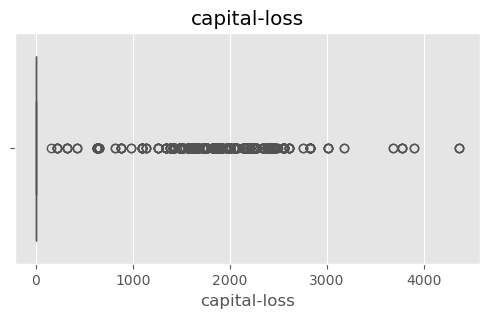

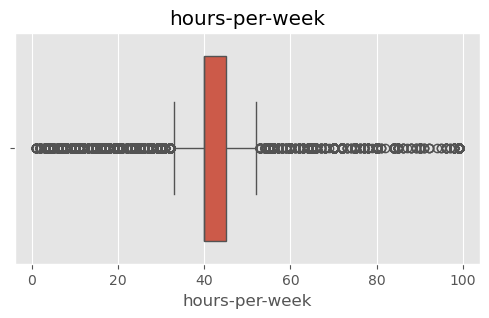

In [72]:
num_cols = adult.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=adult[col])
    plt.title(col)
    plt.show()

## Bivarite Analysis

### Gender vs income 

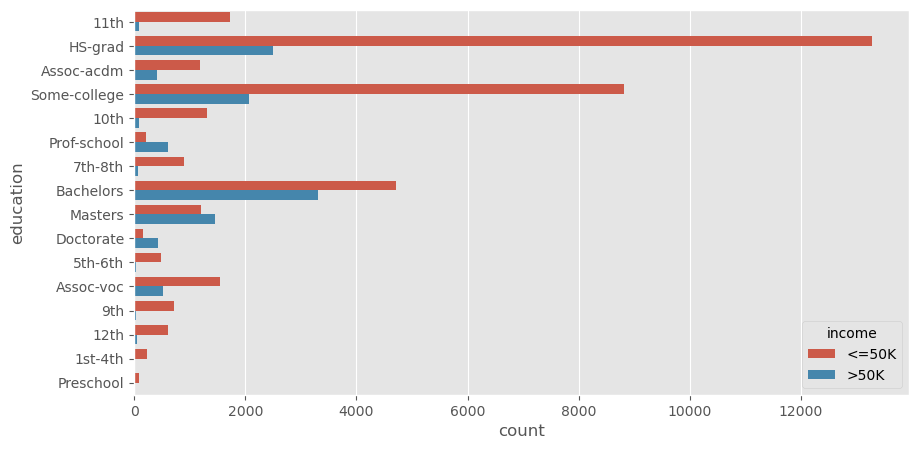

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(y='education',hue='income',data=adult)
plt.show()

### education vs income 

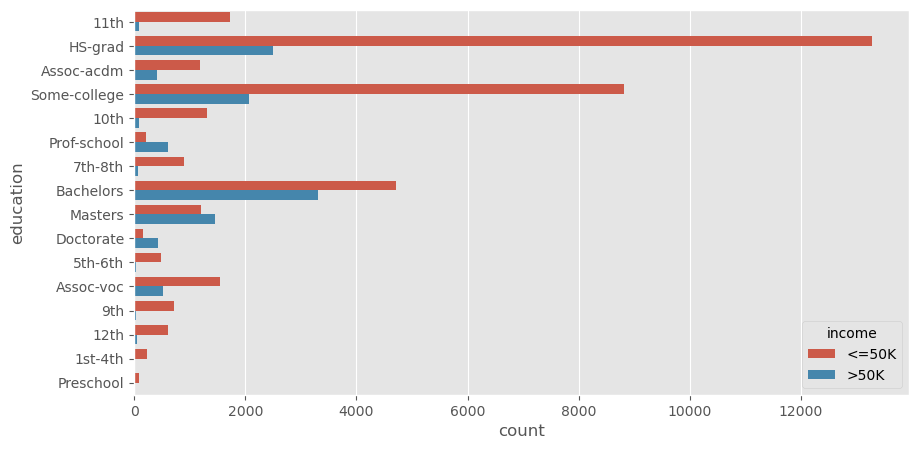

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(y='education',hue='income',data=adult)
plt.show()

### Marital status vs income 

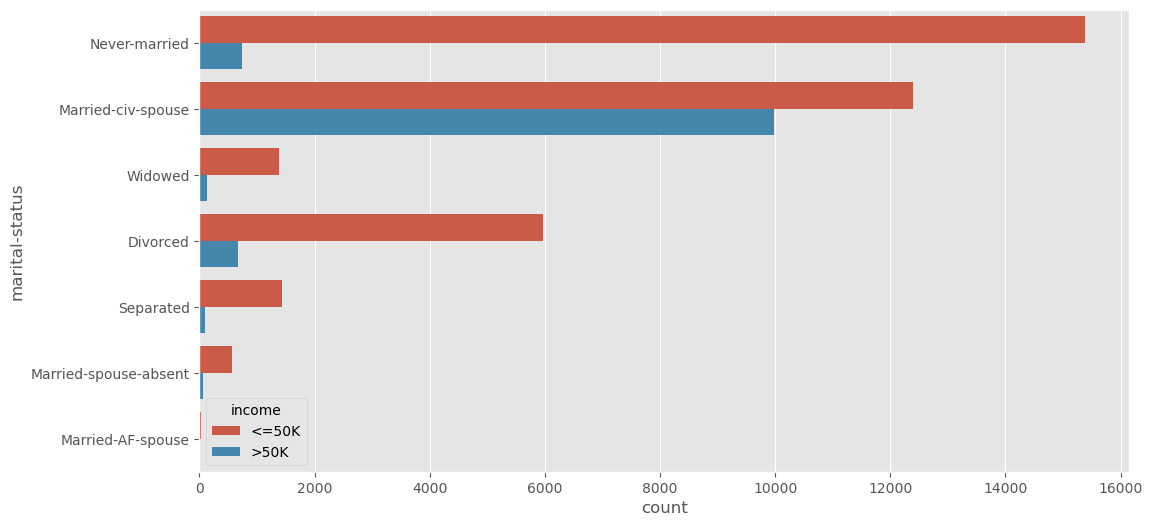

In [12]:
plt.figure(figsize=(12,6))
sns.countplot(y='marital-status',hue='income',data=adult)
plt.show()

### Race vs Income 

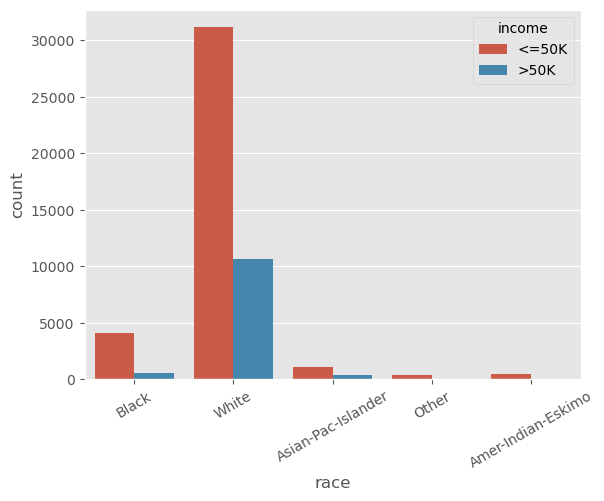

In [13]:
sns.countplot(x='race',hue='income',data=adult)
plt.xticks(rotation=30)
plt.show()

### Workclass vs Income 

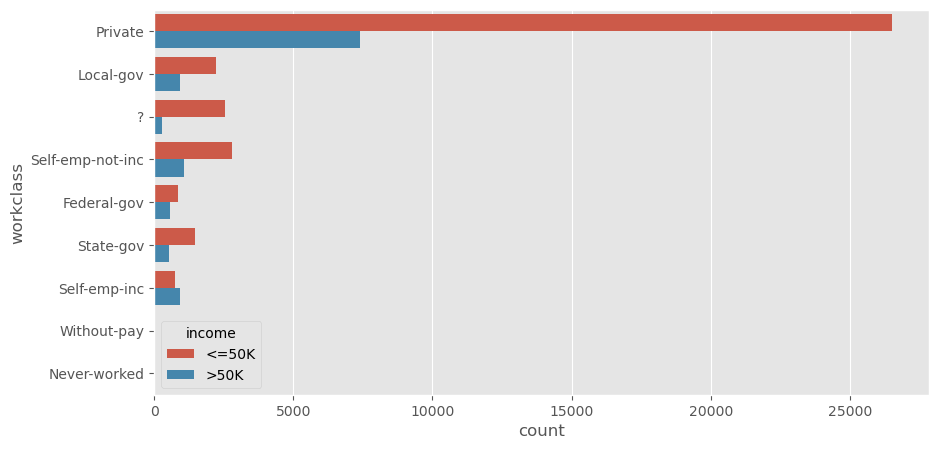

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(y='workclass',hue='income',data=adult)
plt.show()

### hrs / week 

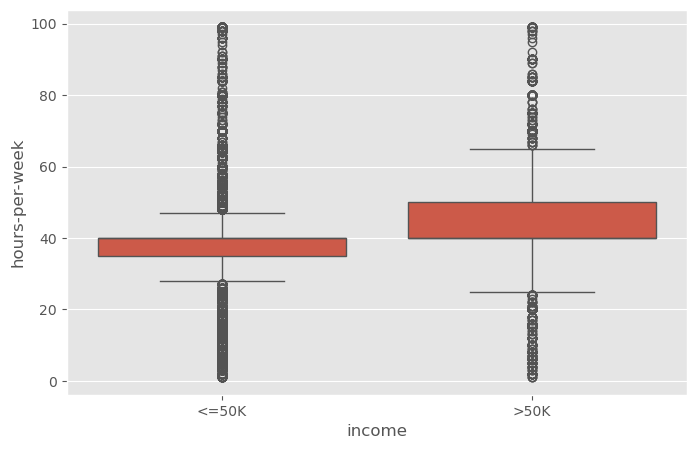

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='income',y='hours-per-week',data=adult)
plt.show()

### Correlation Matrix 

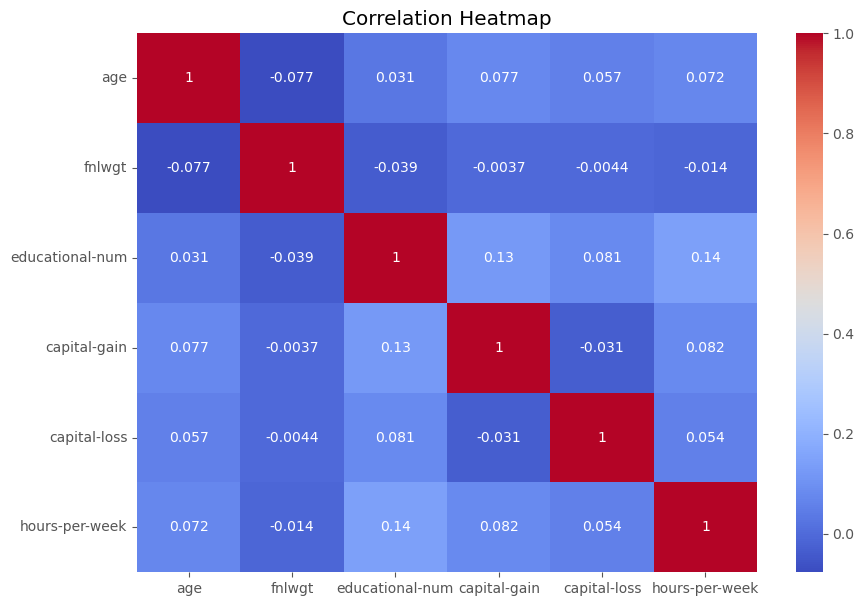

In [16]:
plt.figure(figsize=(10,7))

numeric = adult.select_dtypes(include=np.number)

sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### save file 

In [18]:
adult.to_csv("cleaned_adult.csv", index=False)

print("Adult Dataset Cleaned Successfully.")

Adult Dataset Cleaned Successfully.


# Section 3 : Hotel booking dataset

### Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### Load dataset

In [20]:
hotel = pd.read_csv("hotel_booking.csv")

In [21]:
hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [22]:
hotel.head()

hotel.tail()

hotel.shape

hotel.columns

hotel.info()

hotel.describe()

hotel.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926,81503,115889,119390,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,669-792-1661,************4923
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461,48,6,1,28


### Missing values 

In [23]:
hotel.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## Heatmap

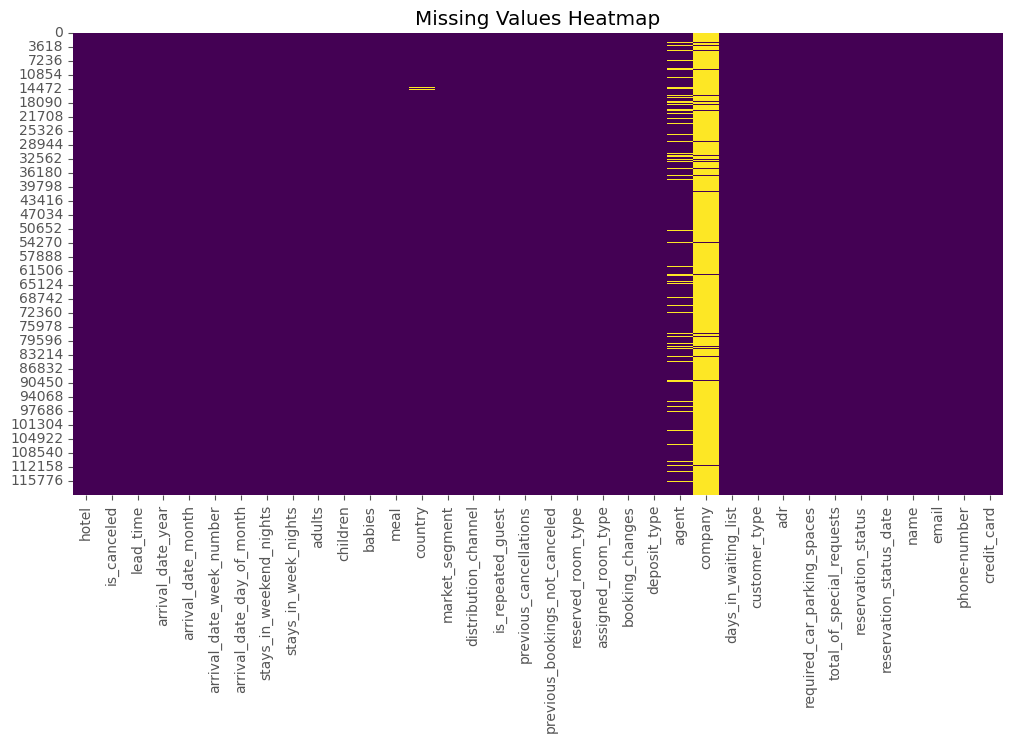

In [25]:
plt.figure(figsize=(12,6))

sns.heatmap(hotel.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()

### Duplicate records

In [26]:
hotel.duplicated().sum()

np.int64(0)

### Data typea

In [27]:
hotel.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

### Value counts 

In [28]:
for col in hotel.columns:
    print("\n",col)
    print(hotel[col].value_counts())


 hotel
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

 is_canceled
is_canceled
0    75166
1    44224
Name: count, dtype: int64

 lead_time
lead_time
0      6345
1      3460
2      2069
3      1816
4      1715
       ... 
400       1
370       1
532       1
371       1
463       1
Name: count, Length: 479, dtype: int64

 arrival_date_year
arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

 arrival_date_month
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

 arrival_date_week_number
arrival_date_week_number
33    3580
30    3087
32    3045
34    3040
18    2926
21    2854
28    2853
17    2805
20    2785
29    2763
42    2756
31    2741
41    2699
15    2689
27    2664
25    2663
38    2661
23    2621

# Data cleaning

### Missing values 

In [29]:
hotel.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [32]:
cat_cols = hotel.select_dtypes(include='object').columns

for col in cat_cols:
    hotel[col].fillna(hotel[col].mode()[0])

In [33]:
num_cols = hotel.select_dtypes(include=np.number).columns

for col in num_cols:
    hotel[col].fillna(hotel[col].median())

In [34]:
hotel.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

## Univarite analysis

### Hotel type

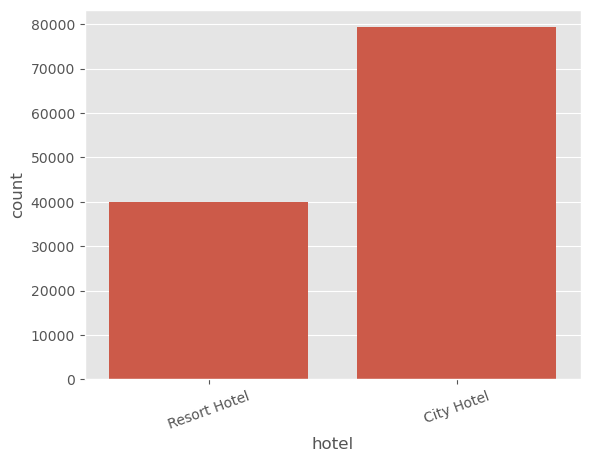

In [35]:
sns.countplot(x='hotel',data=hotel)

plt.xticks(rotation=20)

plt.show()

### Reservation status

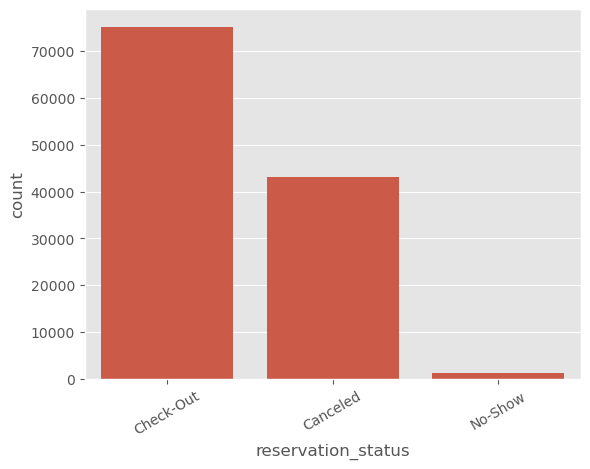

In [37]:
sns.countplot(x='reservation_status',
              data=hotel)

plt.xticks(rotation=30)

plt.show()

### Arrival month 

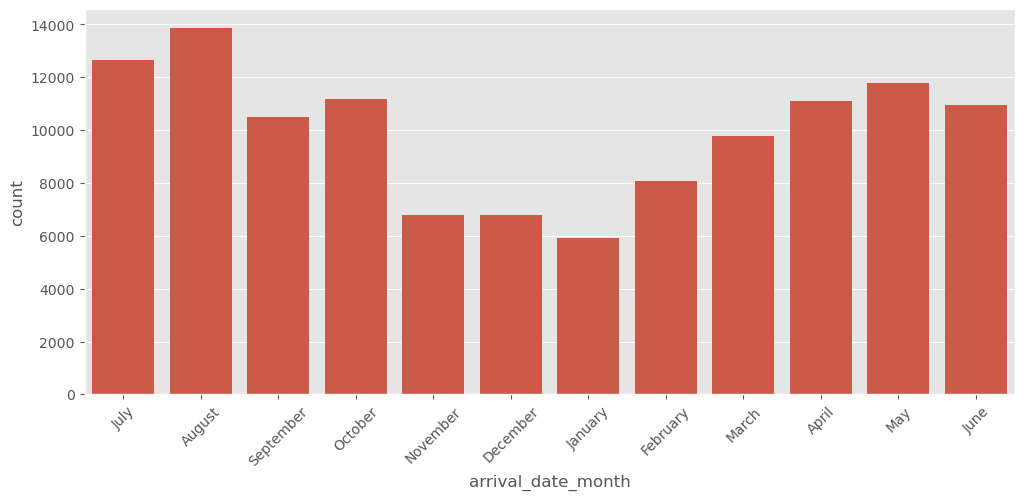

In [38]:
plt.figure(figsize=(12,5))

sns.countplot(x='arrival_date_month',
              data=hotel)

plt.xticks(rotation=45)

plt.show()

### Meal type

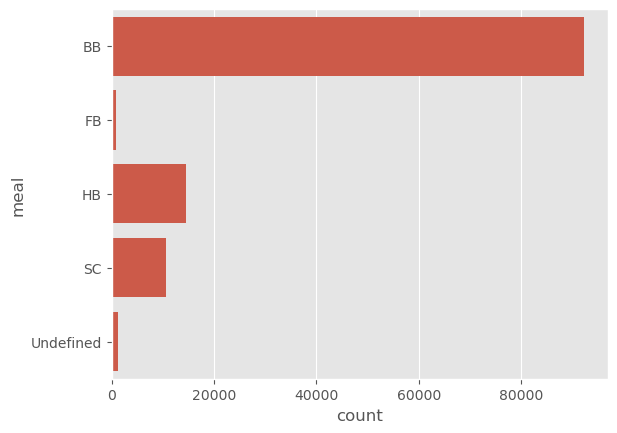

In [39]:
sns.countplot(y='meal',
              data=hotel)

plt.show()

### Market segment

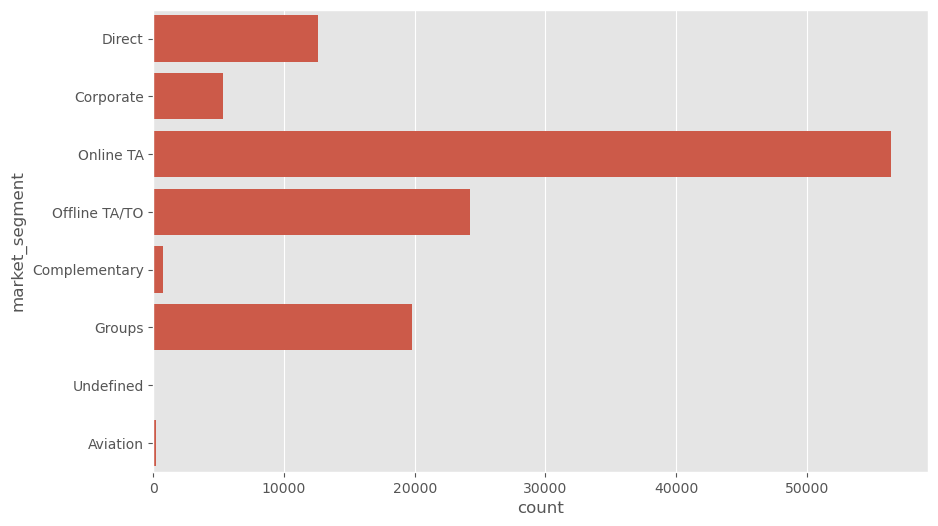

In [40]:
plt.figure(figsize=(10,6))

sns.countplot(y='market_segment',
              data=hotel)

plt.show()

### Distribution channel 

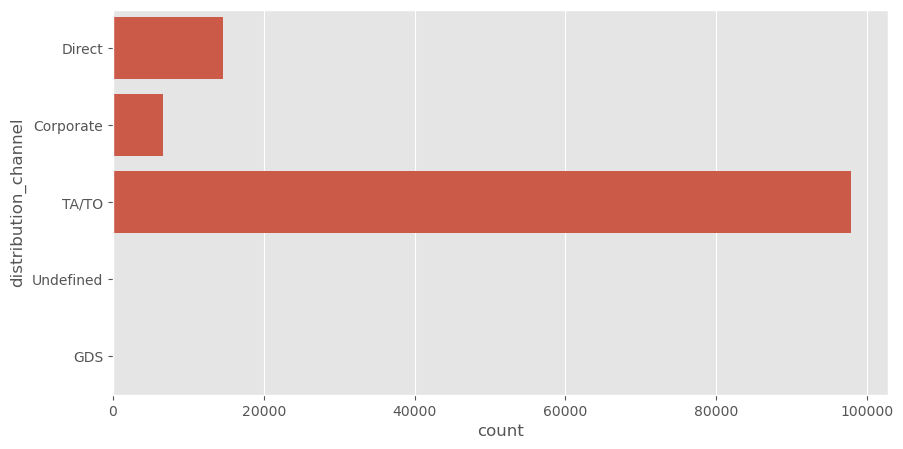

In [41]:
plt.figure(figsize=(10,5))

sns.countplot(y='distribution_channel',
              data=hotel)

plt.show()

### customer type

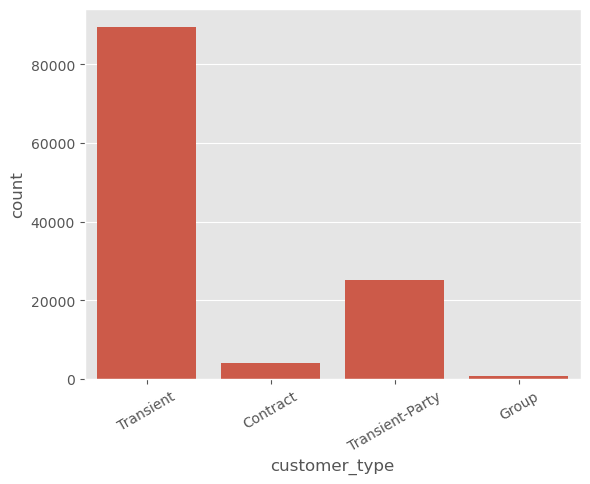

In [42]:
sns.countplot(x='customer_type',
              data=hotel)

plt.xticks(rotation=30)

plt.show()

### Deposit type

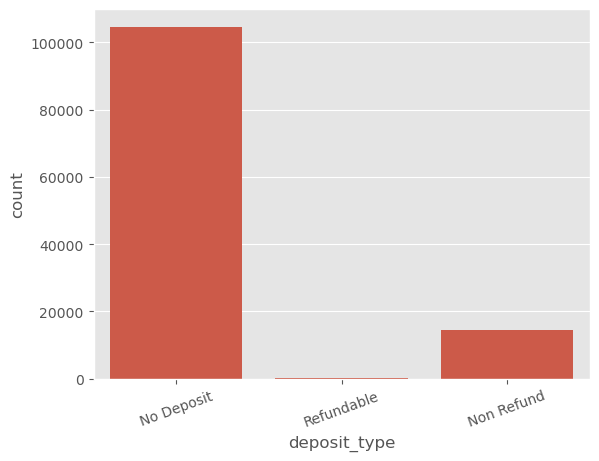

In [43]:
sns.countplot(x='deposit_type',
              data=hotel)

plt.xticks(rotation=20)

plt.show()

### country distribution 

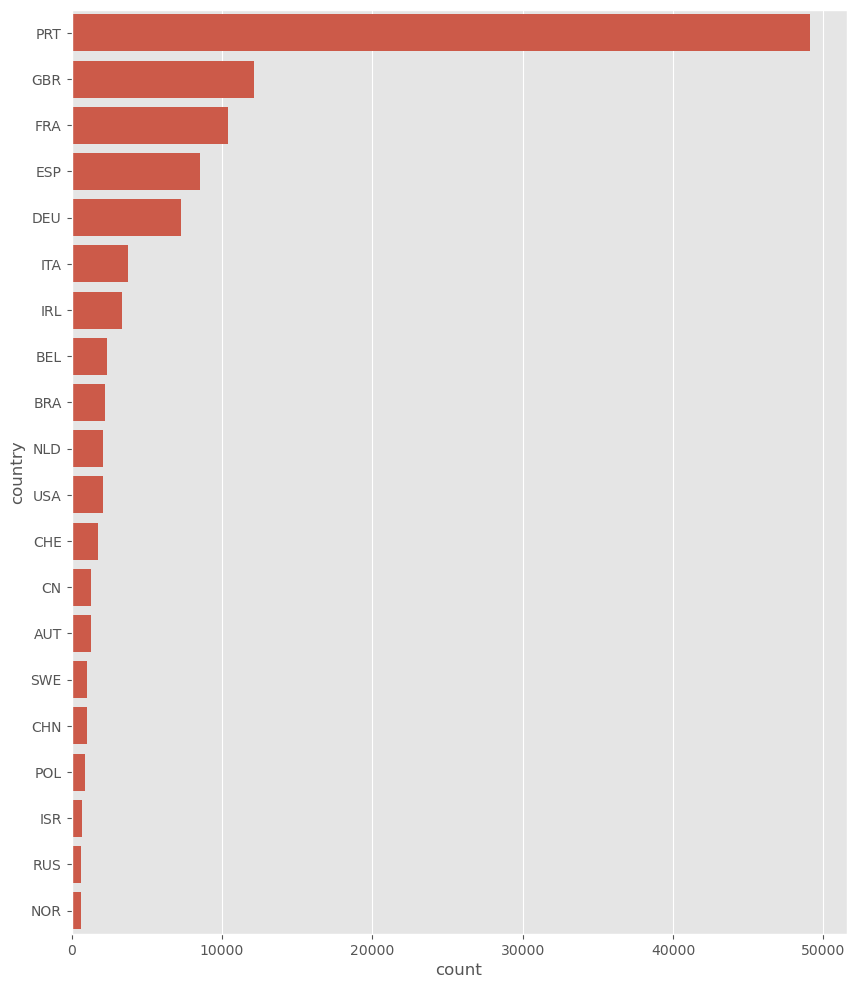

In [44]:
plt.figure(figsize=(10,12))

sns.countplot(y='country',
              data=hotel,
              order=hotel['country'].value_counts().head(20).index)

plt.show()

### Leadtime

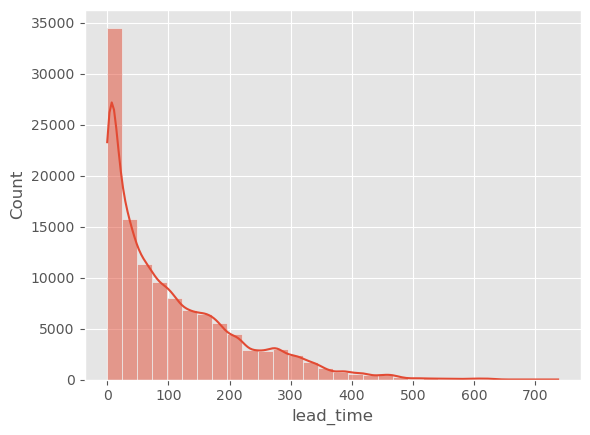

In [45]:
sns.histplot(hotel['lead_time'],
             bins=30,
             kde=True)

plt.show()

## ADR (Average daily rate)

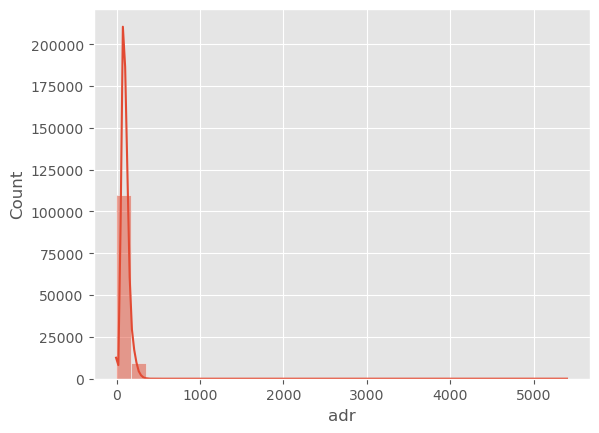

In [46]:
sns.histplot(hotel['adr'],
             bins=30,
             kde=True)

plt.show()

### Adult

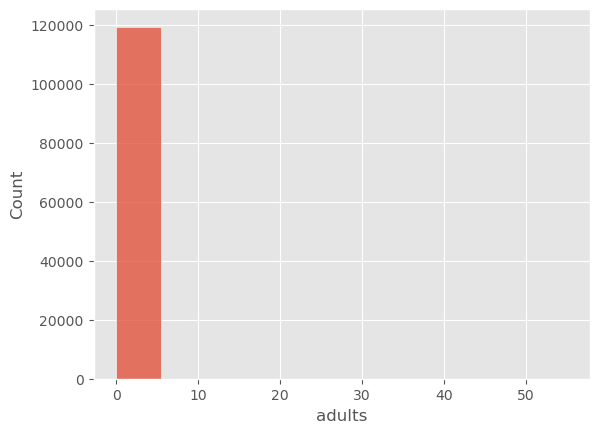

In [47]:
sns.histplot(hotel['adults'],
             bins=10)

plt.show()

### Children 

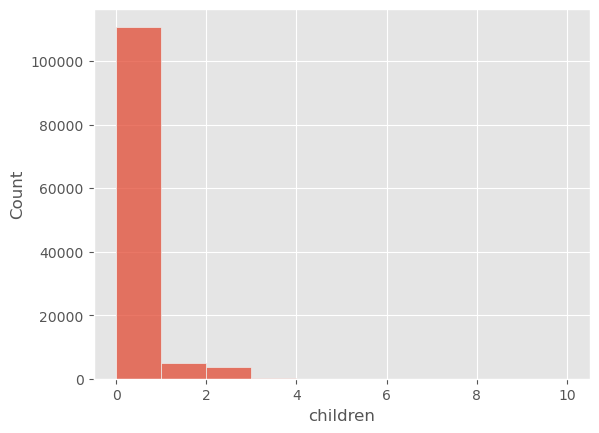

In [48]:
sns.histplot(hotel['children'],
             bins=10)

plt.show()

### Babies

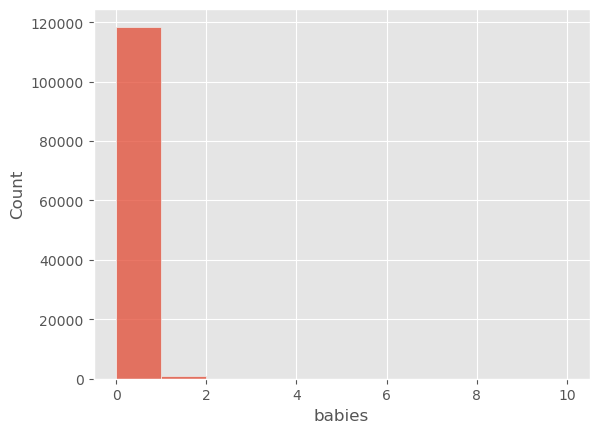

In [49]:
sns.histplot(hotel['babies'],
             bins=10)

plt.show()

## Boxplot 

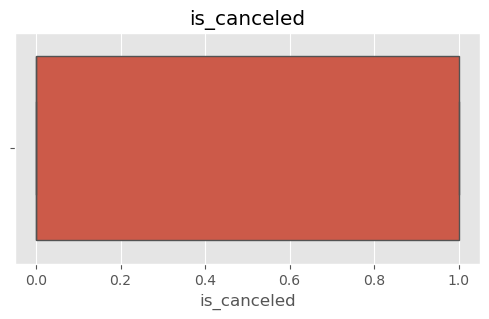

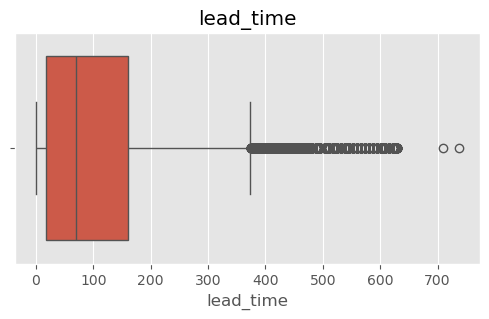

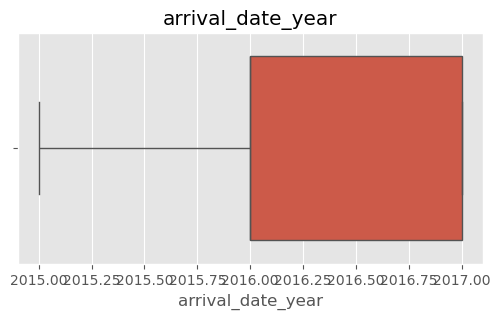

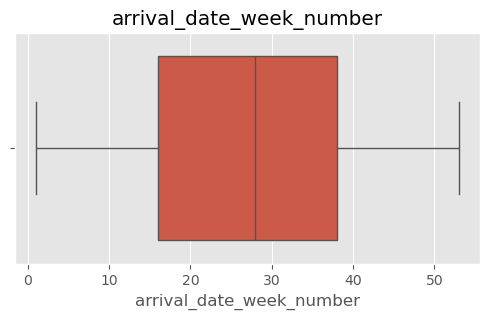

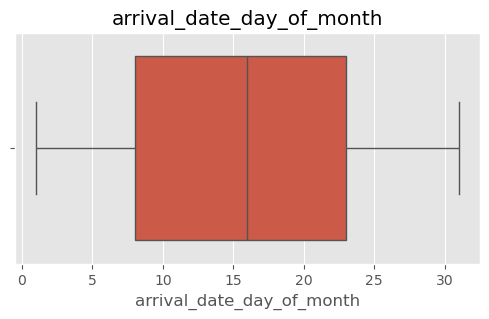

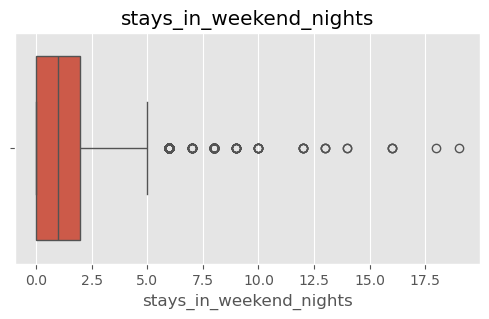

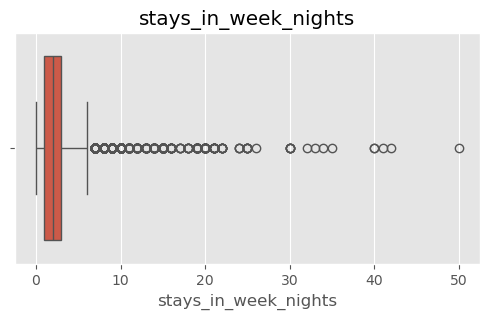

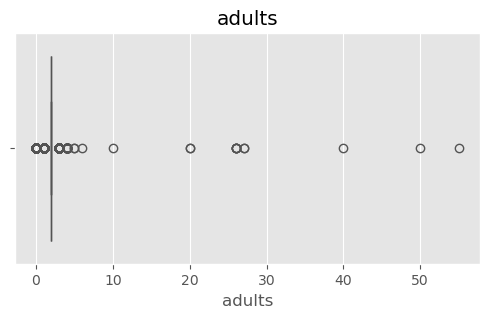

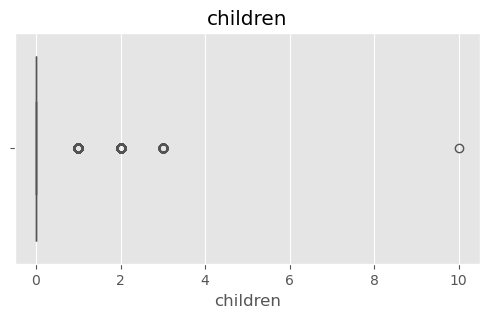

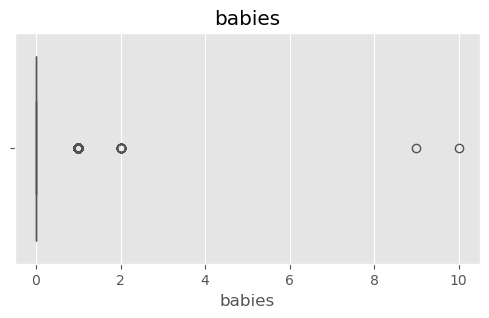

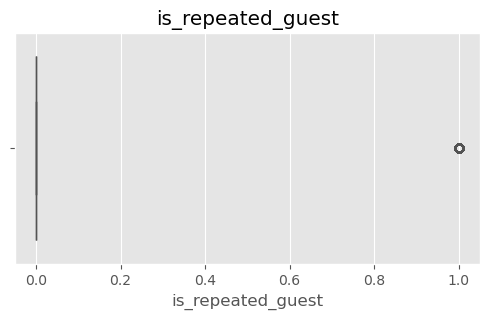

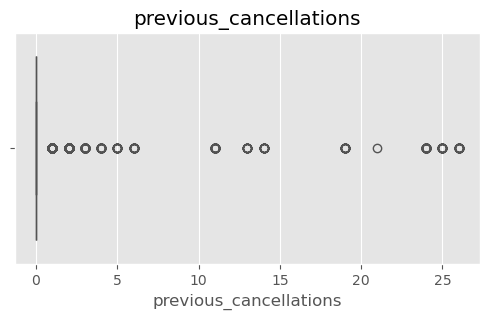

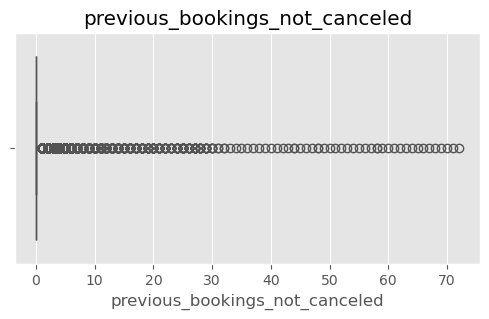

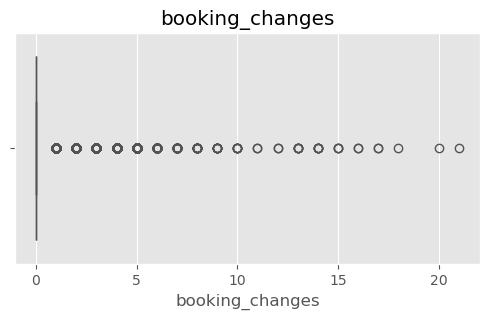

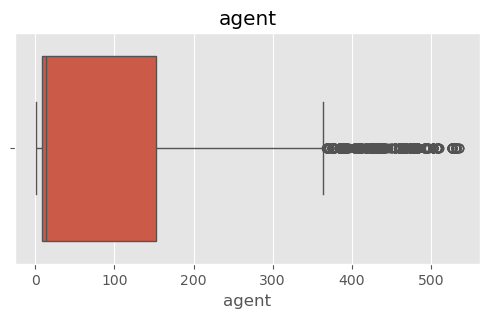

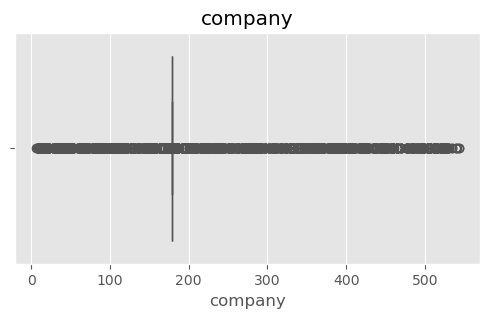

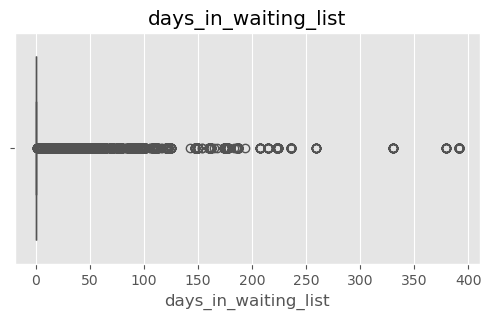

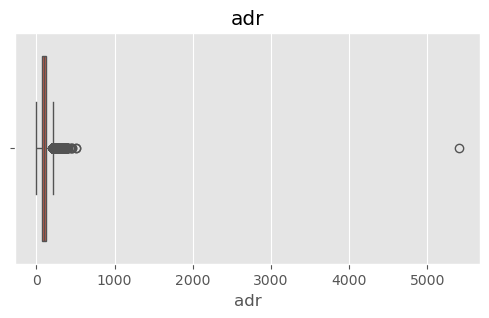

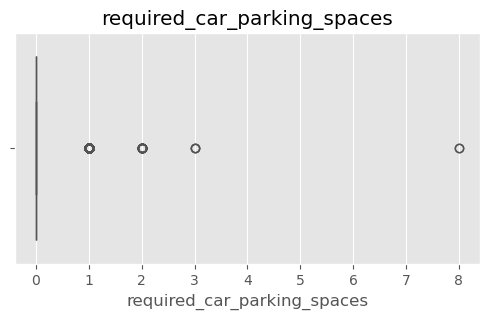

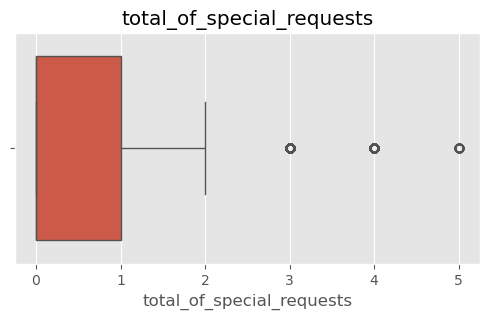

In [50]:
numeric = hotel.select_dtypes(include=np.number).columns

for col in numeric:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=hotel[col])

    plt.title(col)

    plt.show()

In [54]:
# total guest
hotel['Total_Guests'] = hotel['adults'] + hotel['children'] + hotel['babies']
#total nights
hotel['Total_Nights'] = hotel['stays_in_weekend_nights'] + hotel['stays_in_week_nights']


## Bivarite Analysis

### Hotel type vs Cancellation 

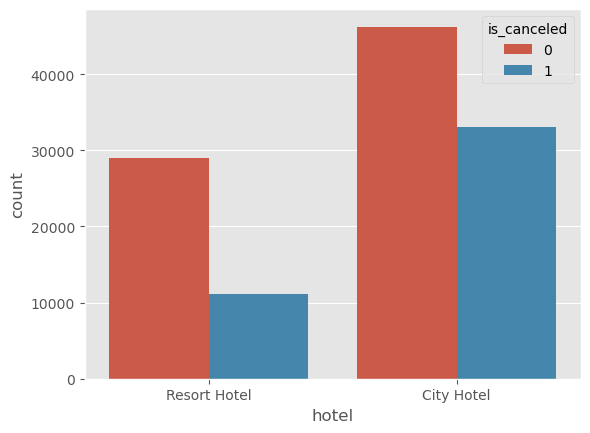

In [55]:
sns.countplot(x='hotel',
              hue='is_canceled',
              data=hotel)

plt.show()

### Customer type vs Cancellation 

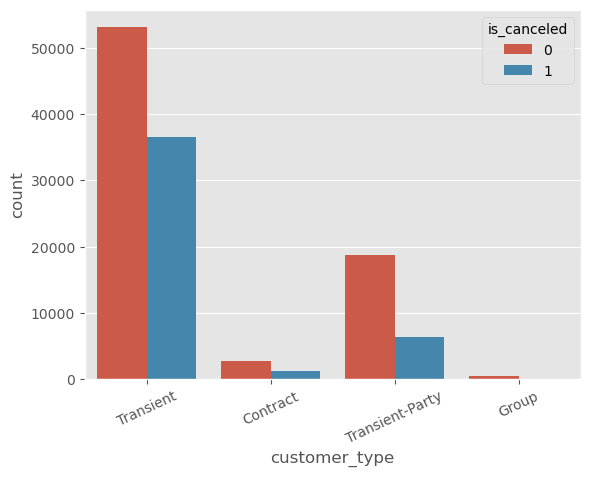

In [56]:
sns.countplot(x='customer_type',
              hue='is_canceled',
              data=hotel)

plt.xticks(rotation=25)

plt.show()

### Deposity type vs Cancellation 

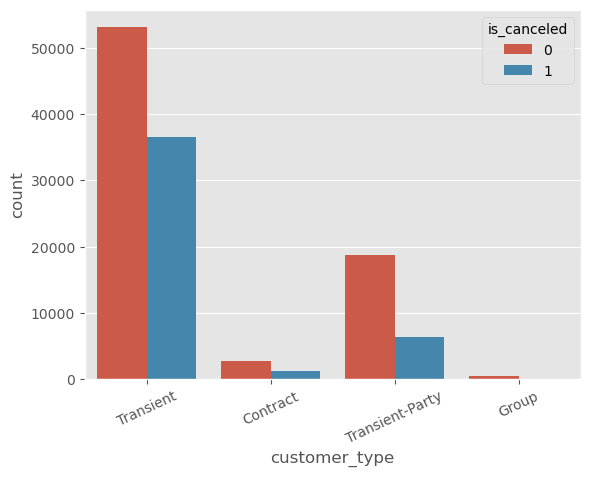

In [57]:
sns.countplot(x='customer_type',
              hue='is_canceled',
              data=hotel)

plt.xticks(rotation=25)

plt.show()

### Market segment vs Cancellation 

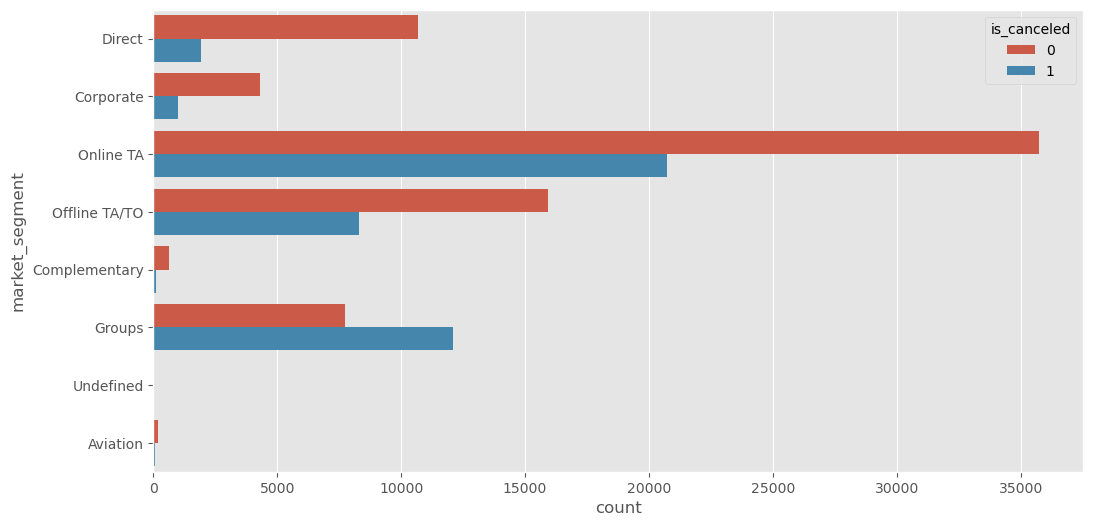

In [58]:
plt.figure(figsize=(12,6))

sns.countplot(y='market_segment',
              hue='is_canceled',
              data=hotel)

plt.show()

### Meal vs cancellation 

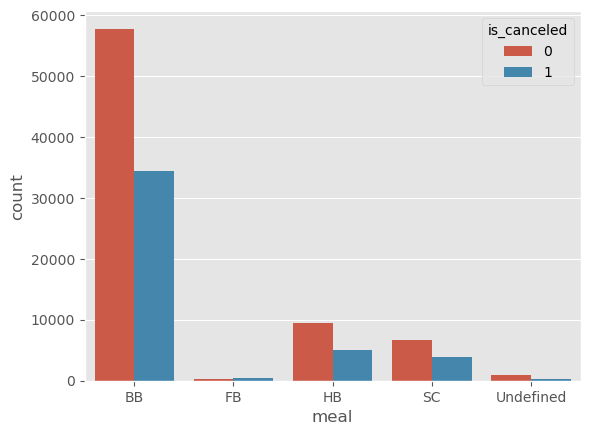

In [59]:
sns.countplot(x='meal',
              hue='is_canceled',
              data=hotel)

plt.show()

### Leadtime vs cancellation 

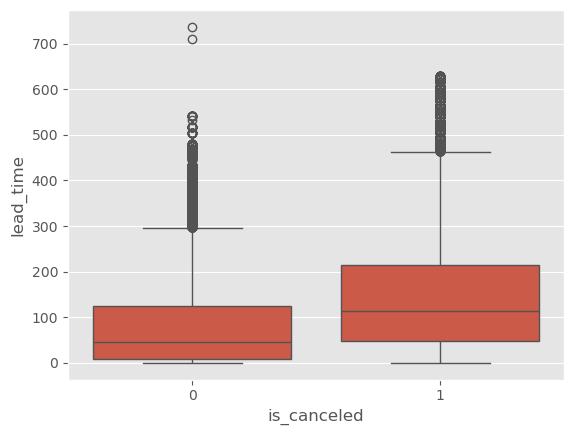

In [60]:
sns.boxplot(x='is_canceled',
            y='lead_time',
            data=hotel)

plt.show()

### ADR VS Hotel type 

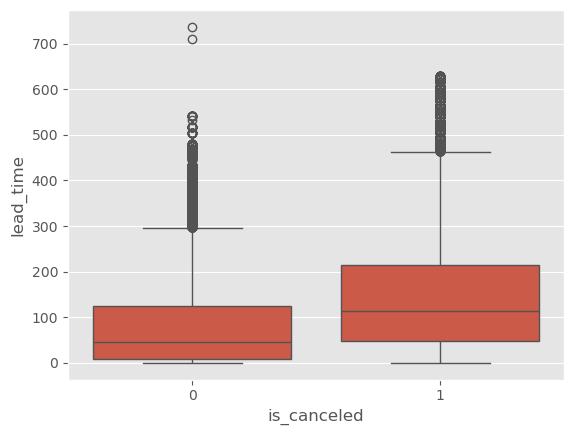

In [61]:
sns.boxplot(x='is_canceled',
            y='lead_time',
            data=hotel)

plt.show()

### Total guest vs Hotel type 

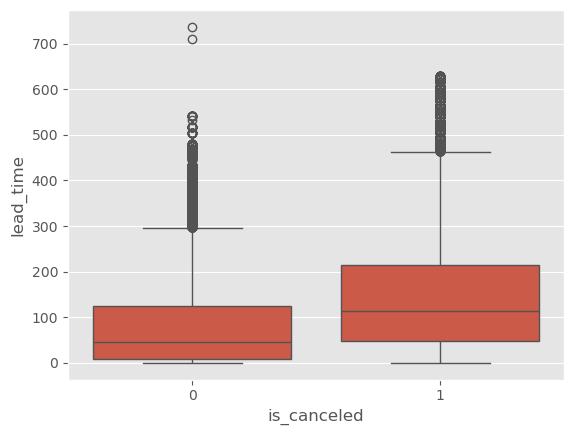

In [62]:
sns.boxplot(x='is_canceled',
            y='lead_time',
            data=hotel)

plt.show()

### Correlation heatmap 

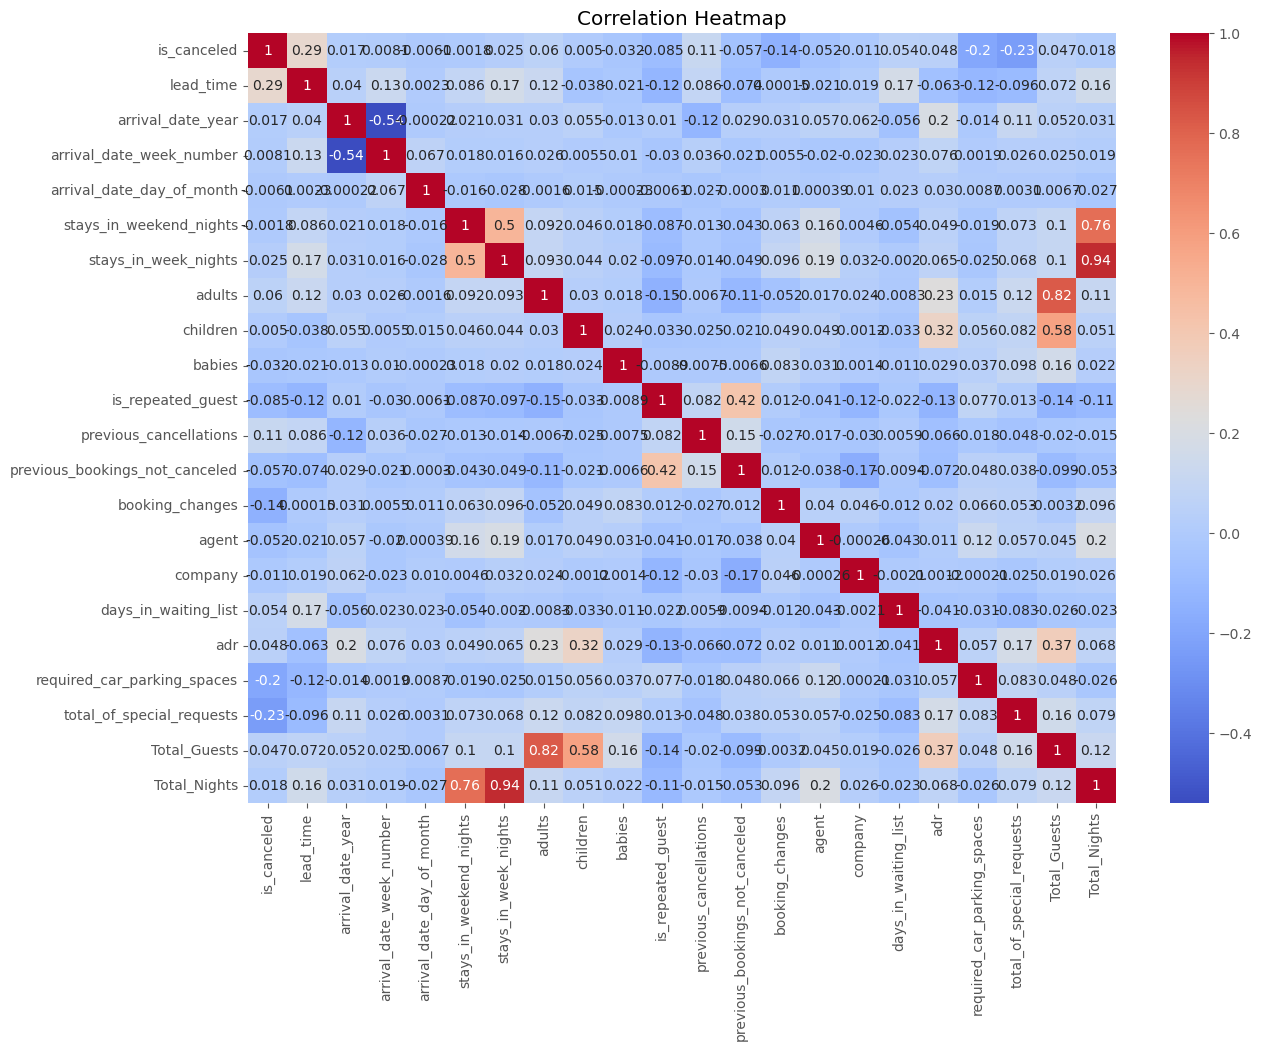

In [63]:
plt.figure(figsize=(14,10))

numeric = hotel.select_dtypes(include=np.number)

sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
sns.pairplot(hotel[['lead_time',
                    'adr',
                    'adults',
                    'children',
                    'Total_Guests',
                    'is_canceled']],
             hue='is_canceled')

plt.show()

### Save clean dataset

In [ ]:
hotel.to_csv("cleaned_hotel_booking.csv",index=False)

print("Hotel Booking Dataset Cleaned Successfully")